# Final Evaluation — LightGBM v1


In [32]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


In [33]:
preprocessor = joblib.load(
    "../models/preprocessor.joblib"
)

model = joblib.load(
    "../models/lightgbm_candidate.joblib"
)

with open("../models/model_metadata.json", "r") as f:
    metadata = json.load(f)

FINAL_THRESHOLD = metadata["threshold"]
categorical_cols = metadata["categorical_cols"]
drop_cols = metadata["drop_cols"]

print("Threshold:", FINAL_THRESHOLD)

Threshold: 0.3828149414598991


In [34]:
test = pd.read_parquet(
    "../data/processed/test.parquet"
)

val = pd.read_parquet(
    "../data/processed/validation.parquet"
)

X_test = test.drop(columns=drop_cols)
y_test = test["is_canceled"]

y_val = val["is_canceled"]

print("Test shape:", test.shape)
print("Cancellation rate:", y_test.mean())

Test shape: (18696, 38)
Cancellation rate: 0.30594779632006847


In [35]:
X_val = val.drop(columns=drop_cols)
y_val = val["is_canceled"]

for col in categorical_cols:
    X_val[col] = (
        X_val[col]
        .astype("object")
        .where(X_val[col].notna(), np.nan)
    )

X_val_enc = preprocessor.transform(X_val)

val_proba = model.predict_proba(X_val_enc)[:, 1]
val_pred = (val_proba >= FINAL_THRESHOLD).astype(int)

In [36]:
for col in categorical_cols:
    X_test[col] = X_test[col].astype("string")


for col in categorical_cols:
    X_test[col] = (
        X_test[col]
        .astype("object")
        .where(X_test[col].notna(), np.nan)
    )


In [37]:
X_test_enc = preprocessor.transform(X_test)

In [38]:
test_proba = model.predict_proba(X_test_enc)[:, 1]

test_pred = (
    test_proba >= FINAL_THRESHOLD
).astype(int)

In [39]:
test_roc_auc = roc_auc_score(y_test, test_proba)
test_pr_auc = average_precision_score(y_test, test_proba)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_pred
).ravel()

test_results = {
    "accuracy": accuracy_score(y_test, test_pred),
    "precision": precision_score(y_test, test_pred),
    "recall": recall_score(y_test, test_pred),
    "f1": f1_score(y_test, test_pred),
    "roc_auc": test_roc_auc,
    "pr_auc": test_pr_auc,
    "tn": tn,
    "fp": fp,
    "fn": fn,
    "tp": tp
}

test_results


{'accuracy': 0.7882969619169876,
 'precision': 0.6165960825833775,
 'recall': 0.8145104895104895,
 'f1': 0.7018680325399217,
 'roc_auc': 0.8772202770256871,
 'pr_auc': 0.7502003179293478,
 'tn': np.int64(10079),
 'fp': np.int64(2897),
 'fn': np.int64(1061),
 'tp': np.int64(4659)}

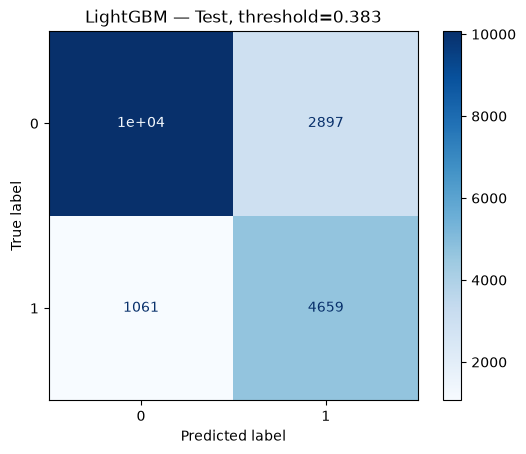

In [40]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred,
    cmap="Blues"
)

plt.title(
    f"LightGBM — Test, threshold={FINAL_THRESHOLD:.3f}"
)
plt.show()


In [41]:
val_results = {
    "precision": precision_score(y_val, val_pred),
    "recall": recall_score(y_val, val_pred),
    "f1": f1_score(y_val, val_pred),
    "roc_auc": roc_auc_score(y_val, val_proba),
    "pr_auc": average_precision_score(y_val, val_proba),
}

In [42]:
comparison = pd.DataFrame([
    {
        "split": "validation",
        **val_results
    },
    {
        "split": "test",
        "precision": test_results["precision"],
        "recall": test_results["recall"],
        "f1": test_results["f1"],
        "roc_auc": test_results["roc_auc"],
        "pr_auc": test_results["pr_auc"]
    }
])

comparison.set_index("split").round(4)

,precision,recall,f1,roc_auc,pr_auc
split,,,,,
validation,0.7099,0.9008,0.7940,0.9254,0.8985
test,0.6166,0.8145,0.7019,0.8772,0.7502


## Вывод

На новом временном периоде качество заметно просело: `ROC-AUC` снизился с 0.925 до 0.875, `PR-AUC` — с 0.899 до 0.748, а `Recall` — с 0.900 до 0.823.

Похоже, test отличается от validation не только по доле отмен, но и по самим признакам. Дальше посмотрю, где именно появился drift и с чем связано падение качества.


## Target drift


In [43]:
target_drift = pd.DataFrame({
    "validation": [y_val.mean()],
    "test": [y_test.mean()]
}, index=["cancellation_rate"])

target_drift

,validation,test
cancellation_rate,0.392804,0.305948


In [44]:
drift_cols = [
    "lead_time",
    "adr",
    "previous_cancellations",
    "previous_bookings_not_canceled"
]

pd.DataFrame({
    "validation_mean": val[drift_cols].mean(),
    "test_mean": test[drift_cols].mean(),
    "validation_median": val[drift_cols].median(),
    "test_median": test[drift_cols].median()
})

,validation_mean,test_mean,validation_median,test_median
lead_time,90.810407,50.066538,77.0,30.0
adr,98.424994,131.992142,93.5,126.0
previous_cancellations,0.013894,0.018346,0.0,0.0
previous_bookings_not_canceled,0.177249,0.281878,0.0,0.0


In [45]:
for col in [
    "hotel",
    "deposit_type",
    "market_segment",
    "customer_type",
    "country_group"
]:
    print(f"\n--- {col} ---")

    comparison = pd.concat(
        [
            val[col].value_counts(normalize=True).rename("validation"),
            test[col].value_counts(normalize=True).rename("test")
        ],
        axis=1
    ).fillna(0)

    display(comparison)


--- hotel ---


,validation,test
hotel,,
City Hotel,0.701633,0.648641
Resort Hotel,0.298367,0.351359



--- deposit_type ---


,validation,test
deposit_type,,
No Deposit,0.847163,0.969084
Non Refund,0.152449,0.030167
Refundable,0.000387,0.000749



--- market_segment ---


,validation,test
market_segment,,
Online TA,0.513811,0.612751
Groups,0.181345,0.053808
Offline TA/TO,0.149792,0.100182
Direct,0.100692,0.162227
Corporate,0.047993,0.055841
Complementary,0.005480,0.009681
Aviation,0.000886,0.005509



--- customer_type ---


,validation,test
customer_type,,
Transient,0.841960,0.877995
Transient-Party,0.144146,0.099700
Contract,0.009798,0.014281
Group,0.004096,0.008023



--- country_group ---


,validation,test
country_group,,
Foreign,0.633878,0.692501
Domestic,0.362081,0.304611
Unknown,0.004041,0.002888


## Итог

На `test` заметно изменилось распределение данных. Сильнее всего сдвинулись `lead_time`, `deposit_type`, `market_segment`, `adr` и `country_group`.

Например, медианный `lead_time` снизился с 77 до 30 дней, а доля `Non Refund` — с 15.2% до 3.0%. Эти признаки ещё на EDA были сильно связаны с отменой бронирования. Одновременно `cancellation rate` снизился с 39.3% на validation до 30.6% на test.

Поэтому падение качества v1 похоже на следствие temporal drift, а не только на недостатки самой модели. Дальше использую более поздние данные как симуляцию production-потока: сначала проверю v1 через FastAPI и мониторинг, затем после появления новых labels переобучу v2 и сравню версии на следующем временном окне.
